In [1]:
import xmitgcm as xm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl
import matplotlib.colors as mcolors
import xhistogram.xarray as xhist
import jmkfigure

<IPython.core.display.Javascript object>

29.958333333333332
[-11.15 -11.05 -10.95 -10.85 -10.75 -10.65 -10.55 -10.45 -10.35 -10.25
 -10.15 -10.05  -9.95  -9.85  -9.75  -9.65  -9.55  -9.45  -9.35  -9.25
  -9.15  -9.05  -8.95  -8.85  -8.75  -8.65  -8.55  -8.45  -8.35  -8.25
  -8.15  -8.05  -7.95  -7.85  -7.75  -7.65  -7.55  -7.45  -7.35  -7.25
  -7.15  -7.05  -6.95  -6.85  -6.75  -6.65  -6.55  -6.45  -6.35  -6.25
  -6.15  -6.05  -5.95  -5.85  -5.75  -5.65  -5.55  -5.45  -5.35  -5.25
  -5.15  -5.05  -4.95  -4.85  -4.75  -4.65  -4.55  -4.45  -4.35  -4.25
  -4.15  -4.05  -3.95  -3.85  -3.75  -3.65  -3.55  -3.45  -3.35  -3.25
  -3.15  -3.05  -2.95  -2.85  -2.75  -2.65  -2.55  -2.45  -2.35  -2.25
  -2.15  -2.05  -1.95  -1.85  -1.75  -1.65  -1.55  -1.45  -1.35  -1.25
  -1.15  -1.05  -0.95  -0.85  -0.75  -0.65  -0.55  -0.45  -0.35  -0.25
  -0.15  -0.05   0.05   0.15   0.25   0.35   0.45   0.55   0.65   0.75
   0.85   0.95   1.05   1.15   1.25   1.35   1.45   1.55   1.65   1.75
   1.85   1.95   2.05   2.15   2.25   2.35   2.45   2.55  

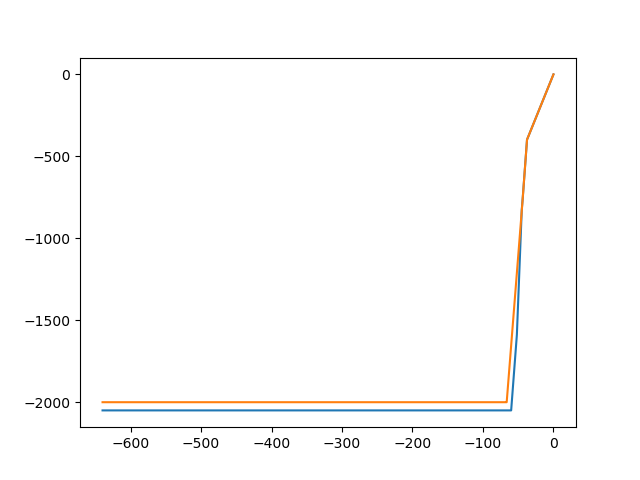

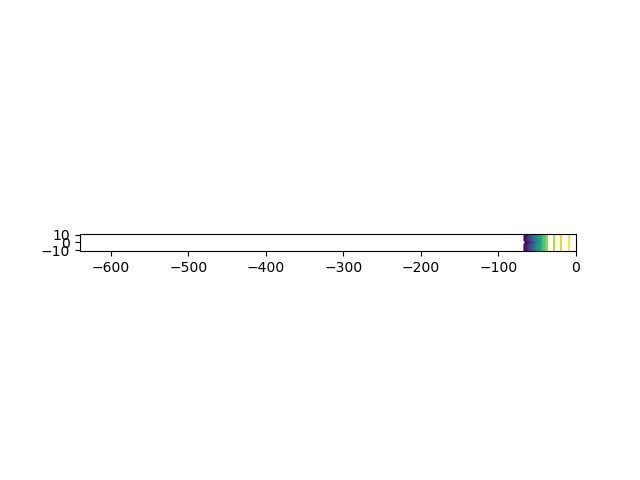

In [107]:
# machines are 192 cores (!)
# So 48 core job maybe good?
# model size
nx = 12*90
# 3.5*4 = 14
ny = 4*56
nz = 200
dx = np.zeros(nx) + 100.0
for i in range(65, -1, -1):
    dx[i] = dx[i + 1] * 1.1
# dx = zeros(nx)+100.
x = np.cumsum(dx)
x = x - x[-1]

dy = np.zeros(ny) + 100.0
y = np.cumsum(dy)
y = y - np.mean(y)

# bathy in canyon from Alford

xx = np.array([10, 18,  24.75, 26, 32.33, 70])
depth = [-2050, -1600, -840, -780, -400, 0]
fig, ax = plt.subplots()
depth = np.interp(x/1e3, xx-xx[-1], depth)
ax.plot(x/1e3, depth)
# slope above:
sl = 120 / 1.25 # m/km
# where would this be at 400 m depth?
x400 = 26 + 380 / sl
print(x400)



sl = 440 / 8
xx2 = np.array([24.75-(2000-840)/sl, 24.75, 26, 32.33, 70])
depth2 = [-2000, -840, -780, -400, 0]
depth2 = np.interp(x/1e3, xx2-xx2[-1], depth2)

ax.plot(x/1e3, depth2)

depths = np.zeros((ny, nx))
# Fill the rows of `depths` with depth2:
depths[:] = depth2

# smooth in the y-direction so it is more of a trench
for i in range(nx):
    depths[:, i] = np.interp(y/1e3, np.array([-20, -3, 0, 3, 20]), np.array([depth2[i], depth2[i], depth[i], depth2[i], depth2[i]]))
fig, ax = plt.subplots()
#ax.pcolormesh(depths)
ax.contour(x/1e3, y/1e3, depths, levels=np.arange(-2000, 0, 100))
ax.set_aspect('equal')
print(y/1e3)
print(depths[:, -550])
depths[depths<-2000] = -2000




{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Tue Aug 12 15:20:17 2025', '__version__': '1.0', '__globals__': [], 'CTD': array([[(array([[11.83439453],
               [11.82024609],
               [11.80609766],
               ...,
               [        nan],
               [        nan],
               [        nan]], shape=(1351, 1)), array([[35.27545703],
               [35.28170937],
               [35.28796172],
               ...,
               [        nan],
               [        nan],
               [        nan]], shape=(1351, 1)), array([[   0],
               [   2],
               [   4],
               ...,
               [2696],
               [2698],
               [2700]], shape=(1351, 1), dtype=uint16), array([[0.00000000e+00],
               [2.01402404e+00],
               [4.02804808e+00],
               ...,
               [2.72512593e+03],
               [2.72715189e+03],
               [2.72917784e+03]], shape=(1351, 1)), array([[1]], d

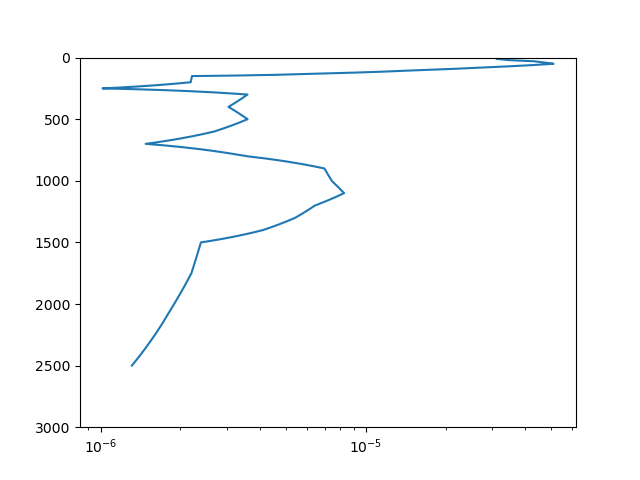

In [ ]:
# read BLT_CTD.mat:
import scipy.io
data = scipy.io.loadmat('BLT_CTD.mat')
print(data)
print(data['CTD'][0][0][-4])
N2 = data['CTD'][0][0][-4]
z = data['CTD'][0][0][2]
N2 = N2[z<=2500]
z = z[z<=2500]
fig, ax  = plt.subplots()
ax.semilogx(N2, z)
ax.set_ylim(3000, 0)
# save as text file z, N2
np.savetxt('N2.txt', np.column_stack((z.flatten(), N2.flatten())), header='z N2')


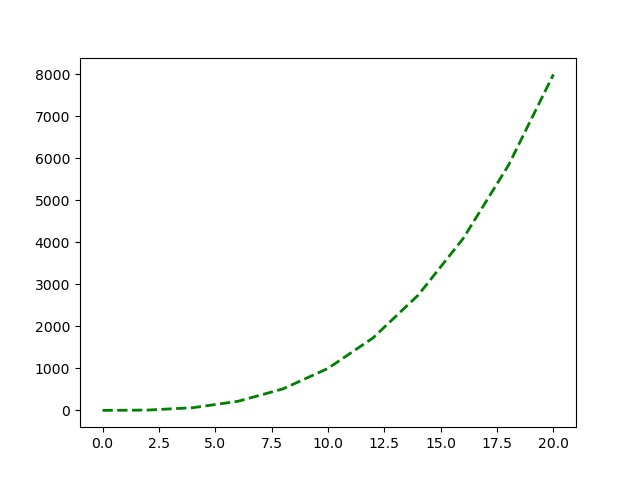

In [110]:
# make an array from 0 to 20 every 2:
x = np.arange(0, 21, 2)
# Plot versus the cube of x versus itself:
y = x**3
fig, ax = plt.subplots()
# make the line dashed and thicker and green:
ax.plot(x, y, linestyle='--', linewidth=2, color='green')
